In [3]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm

# 概率比较部分
from scipy.special import gammaln
import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation
import importlib

import os
import glob
import re

Trans into torch tensor input


In [5]:
file_load_once = 100
param = 0

test_DE_sim = DESimulation('DE_param_30_test.yaml')

muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = param * file_load_once + i
    filename = test_DE_sim.load_folder_path + \
        "muon_track/muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)
    
# 根据生成的muon模拟file生成对应的延迟电子
print("############# \n Start generating DEs \n #############")
test_DE_sim.generate_muon_points(muon_file_list)

############# 
 Start generating DEs 
 #############


  7%|█████████▌                                                                                                                              | 7/100 [00:00<00:01, 64.64it/s]

/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.0.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.1.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.2.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.3.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.4.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.5.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.6.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.7.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.8.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.9.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.10.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.11.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.12.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.13.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon

 36%|████████████████████████████████████████████████▏                                                                                     | 36/100 [00:00<00:00, 128.51it/s]

/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.15.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.16.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.17.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.18.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.19.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.20.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.21.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.22.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.23.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.24.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.25.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.26.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.27.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.28.npy
/home/cchang/RELICS_DE_sim/file_to

...

/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.90.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.91.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.92.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.93.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.94.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.95.npy


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 98/100 [00:02<00:00, 24.52it/s]

/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.96.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.97.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.98.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.99.npy


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 35.45it/s]


Number of muon events: 314337
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]


In [6]:
test_DE_sim.dense_muon_points

array([(     0,  22.,  35.50886603, 133.14609447, -202.17887819, 1.16115860e-01, 1119,  1),
       (     0,  22.,  35.46592525, 133.10993122, -202.24272791, 1.16115860e-01, 1119,  1),
       (     0,  22.,  35.42298446, 133.07376798, -202.30657762, 1.16115860e-01, 1119,  1),
       ...,
       (314336, 194., -48.30771049,  66.6252511 , -207.22813356, 3.06668596e+04, 9722, 11),
       (314336, 194., -47.89994286,  66.19782323, -207.86406678, 3.06668596e+04, 9722, 11),
       (314336, 194., -47.49217522,  65.77039536, -208.5       , 3.06668596e+04, 9722, 11)],
      dtype=[('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')])

In [24]:
gap = 1e-3
t_short_range = np.arange(0,2,gap)
rate_t_short_range = t_short_range**-1.1

/tmp/ipykernel_2042182/2709532751.py:3: RuntimeWarning: divide by zero encountered in power
  rate_t_short_range = t_short_range**-1.1


In [47]:
k = 0.001 / (np.sum(rate_t_short_range[int(2e-3 / gap):]) * gap)
single_e_rate = k*rate_t_short_range
single_e_rate[:2] = 0

In [48]:
t_line = np.arange(0,6,gap)
dense_muon_t_range = test_DE_sim.dense_muon_points[test_DE_sim.dense_muon_points['muon_time'] < 4]

In [71]:
rate_DE = np.zeros(len(t_line))
rate_4e = np.zeros(len(t_line))

for i in tqdm(range(len(dense_muon_t_range))):
    point = dense_muon_t_range[i]
    time_move = int(point['muon_time'] / gap)
    rate =  single_e_rate* point['num_e']
    rate_DE[time_move:time_move + len(t_short_range)] = rate_DE[time_move:time_move + len(t_short_range)] + rate
p = rate_DE * 1.5e-6
rate_4e = (p**3 - p**4) * rate_DE
    

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4700/4700 [00:00<00:00, 81579.63it/s]


In [93]:
np.mean(p)

0.03807965

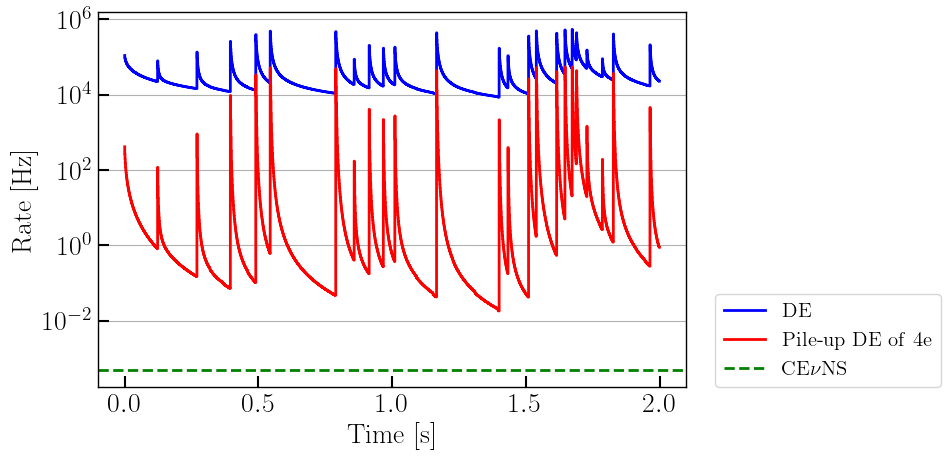

In [91]:
rate_cevns = 1.5e4 / (365 * 24 * 3600)
fig, ax = plt.subplots(figsize=(10, 5))
plt.style.use('../relics.mplstyle')
# 创建一个柱状图并添加误差条
# ax.bar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate_original, edgecolor = "black", label=r"DE",width=10,)
# ax.bar((bins_edge[1:] + bins_edge[:-1])/2, cevns_rate_original, edgecolor = "black", label=r"CE$\nu$NS",width=10,)
ax.plot(t_line[2000:4000] - 2,rate_DE[2000:4000], '-', c='b', label=r'$\mathrm{DE}$',drawstyle='steps')
ax.plot(t_line[2000:4000] - 2,rate_4e[2000:4000], '-', c='r', label=r'$\mathrm{Pile\text{-}up\ DE\ of\ 4e}$',drawstyle='steps') 
ax.axhline(y=rate_cevns, color='g', label=r'$\mathrm{CE\nu NS}$',linestyle='--')

ax.set_xlabel(r"$\mathrm{Time\ [s]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [Hz]}$")
ax.set_yscale("log")

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left', borderaxespad=0.)
plt.tight_layout()
plt.savefig("DE_rate_trange_.pdf")
plt.show()

In [35]:
time_move + len(t_short_range)

3092

In [29]:
time_move

1996.011554317776